# Data-Driven Prediction of Vibrational Entropy Using PhononDB and Materials Descriptors

## Overview
Understanding vibrational entropy is essential for predicting finite-temperature thermodynamic stability, phase transformations, and diffusion behavior in crystalline materials. Within the harmonic approximation, vibrational entropy can be computed from phonon spectra; however, high-throughput evaluation remains computationally expensive due to the need for dense Brillouin zone sampling and second-order interatomic force constants (IFCs).

In this work, we develop a reproducible and scalable framework to compute and model vibrational entropy using data-driven approaches.

---

## Vibrational Entropy Calculation
Vibrational entropy values are obtained from the PhononDB dataset using a custom implementation:

At 300 K:
- `SVib_kB_PhononDB.py`
- Based on **Phonopy** for phonon calculations
- Uses a **20 × 20 × 20 q-point mesh** for convergence

At 100-500K at 50 K interval:
- `SVib_kB_PhononDB_T.py`
- Based on **Phonopy** for phonon calculations
- Uses a **20 × 20 × 20 q-point mesh** for convergence

The entropy is evaluated in units of **k<sub>B</sub> per atom**, ensuring consistency and comparability across materials.

---

## Feature Engineering
To enable predictive modeling, the dataset is augmented with descriptors from:

- **Materials Project** (structure and computed properties)
- **Magpie** (composition-based statistical descriptors)

These features capture:
- Elemental statistics  
- Electronic structure proxies  
- Crystal chemistry information  

---

## Data Cleaning Pipeline
A systematic preprocessing workflow is applied to ensure data quality and robustness:

1. **Removal of Low-Variance Features**
   - Columns where **≥ 90% values are identical** are removed  
   - Eliminates near-constant and uninformative features  

2. **Removal of Columns with High Missing Values**
   - Features with **≥ 10% missing values** are discarded  
   - Ensures reliability of retained descriptors  

3. **Removal of Rows with Remaining Missing Values**
   - Any rows containing missing values are removed  
   - Produces a fully complete dataset for ML models  

4. **Removal of Highly Correlated Features**  
   To reduce redundancy and multicollinearity:
   - The **absolute Pearson correlation matrix** is computed for all numerical features  
   - For each pair with **|r| ≥ 0.8**, one feature is removed  
   - The feature with the **lower absolute correlation with the target variable (Svib\_300K\_kB\_atom)** is discarded, while the more relevant feature is retained  
---


## Neural Network Models
Feedforward neural networks with a **single hidden layer** are trained with:

- 2 nodes  
- 4 nodes  
- 8 nodes  
- 16 nodes  

The final model is selected based on:
- Best predictive performance  
- Minimum model complexity  

---

## Model Interpretability
Feature importance is analyzed using:

- **SHAP (SHapley Additive exPlanations)**  

This enables:
- Identification of dominant features  
- Physical interpretation of learned relationships  
- Insight into structure–property correlations  

---

## Regression Models
To maintain interpretability, multiple regression approaches are explored using top feature:

- Linear regression  
- Logarthmic regression  
- Logarthmic-Linear regression  
  
---
## Temperature-dependent vibrational entropy modeling


To account for the distinct physical behavior of lattice vibrations at different temperatures, a piecewise functional form was adopted. The transition temperature \($T_c$\) separating the low- and high-temperature regimes was determined directly from the data by minimizing validation error.

The final model is expressed as:

- **Low temperature regime (\($T < T_c$\))**  
  \[
  $S_{vib} = a_1 \log(x) + b_1 x + c_1 T^3 + d_1$
  \]

- **High temperature regime (\($T \ge T_c$\))**  
  \[
  $S_{vib} = a_2 \log(x) + b_2 x + c_2 \log(T) + d_2$
  \]

where \(x\) denotes `density_atomic` (Å³/atom) and \(T\) is the temperature in Kelvin.

The \($T^3$\) dependence in the low-temperature regime is consistent with the Debye model, reflecting the suppression of phonon modes, while the logarithmic dependence at higher temperatures captures the gradual saturation of vibrational entropy.

---

## Objective
This workflow provides a consistent and physically grounded approach to:

- Link lattice dynamics with data-driven models  
- Enable rapid prediction of vibrational entropy  
- Maintain a balance between **accuracy, interpretability, and efficiency**   

In [ ]:
!pip install  numpy scipy pandas matminer
!pip install --upgrade mp-api pymatgen
!pip install -U scikit-learn
!pip install mendeleev
!pip install "numpy<1.24.0"
!pip install shap
!pip install --force-reinstall tensorflow==2.15.0 tensorflow-intel==2.15.0 tensorflow-estimator==2.15.0


  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.8 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
ERROR: Could not find a version that satisfies the requirement tensorflow==2.

## Import Libraries and Configure Materials Project API Access

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================
import os
import warnings
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import simpson
from scipy.constants import k, hbar, h

from mp_api.client import MPRester
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model

import shap
import joblib
import pickle

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ------------------------------------------------------------
# Configure Materials Project API Key
# ------------------------------------------------------------
# Replace with your actual Materials Project API key
os.environ["MP_API_KEY"] = "LsPkUsv5pgQP2N75S3mFlgv5wZhqCoys"
API_KEY = os.getenv("MP_API_KEY")

print("Materials Project API key configured successfully.")

Materials Project API key configured successfully.


## Load Vibrational Entropy Data from PhononDB dataset

We load the dataset containing Materials Project IDs and corresponding vibrational entropy values (at 300 K, in k<sub>B</sub>/atom).

In [ ]:
# Load dataset
df = pd.read_csv("SVib_kB_PhononDB.csv")

# Standardize column names
df.columns = ["material_id", "Svib_300K_kB_atom"]

# Quick check
df.head()

,material_id,Svib_300K_kB_atom
0,mp-1000,6.262173
1,mp-10009,5.022012
2,mp-10070,2.537034
3,mp-10074,4.747440
4,mp-10080,2.056497


## Generate Materials Project Features

Using the material IDs from the PhononDB dataset, we retrieve an extended set of structural, thermodynamic, electronic, magnetic, elastic, dielectric, and surface properties from the Materials Project database.

In [ ]:

# ------------------------------------------------------------
# Materials Project feature list
# ------------------------------------------------------------
mp_feature_list = [
    "material_id",

    # ---------------- Composition----------------
    "formula_pretty",
    "formula_anonymous",

    # ---------------- Structural ----------------
    "nsites", "nelements", "volume", "density", "density_atomic",
    "symmetry", "crystal_system", "spacegroup_number", "point_group",
    "theoretical",

    # ---------------- Thermodynamic ----------------
    "formation_energy_per_atom", "energy_per_atom",
    "energy_above_hull", "is_stable",
    "uncorrected_energy_per_atom", "enthalpy",
    "deprecated",

    # ---------------- Electronic ----------------
    "band_gap", "cbm", "vbm", "efermi",
    "is_gap_direct", "is_metal",

    # ---------------- Magnetic ----------------
    "is_magnetic", "ordering",
    "total_magnetization",
    "total_magnetization_normalized_vol",
    "total_magnetization_normalized_formula_units",
    "num_magnetic_sites", "num_unique_magnetic_sites",

    # ---------------- Elastic ----------------
    "bulk_modulus", "shear_modulus",
    "k_voigt", "k_reuss", "k_vrh",
    "g_voigt", "g_reuss", "g_vrh",
    "universal_anisotropy",
    "youngs_modulus",
    "homogeneous_poisson",

    # ---------------- Dielectric ----------------
    "e_total", "e_ionic", "e_electronic",
    "n", "e_ij_max",

    # ---------------- Surface ----------------
    "weighted_surface_energy", "shape_factor",

    # ---------------- Additional ----------------
    "piezoelectric_modulus",
    "surface_anisotropy",
    "formation_energy",
]

# ------------------------------------------------------------
# Retrieve features
# ------------------------------------------------------------
BATCH_SIZE = 500

material_ids = df["material_id"].dropna().unique()
batches = np.array_split(material_ids, len(material_ids)//BATCH_SIZE + 1)

mp_records = []

with MPRester(API_KEY, mute_progress_bars=True) as mpr:
    for batch in tqdm(batches, desc="MP batch queries"):
        try:
            docs = mpr.summary.search(material_ids=list(batch))

            for doc in docs:
                record = {"material_id": doc.material_id}

                for field in mp_feature_list:
                    if field != "material_id":
                        try:
                            record[field] = getattr(doc, field, None)
                        except:
                            record[field] = None

                mp_records.append(record)

        except Exception as e:
            print(f"Batch failed: {e}")

# Convert to DataFrame
df_mp = pd.DataFrame(mp_records)

print(f"Retrieved materials: {len(df_mp)}")

# ---------------- Save ----------------
df_mp.to_csv("mp_features.csv", index=False)
df_mp.to_pickle("mp_features.pkl")

df_mp.head()

MP batch queries: 100%|██████████| 21/21 [01:28<00:00,  4.20s/it]


Retrieved materials: 9939


,material_id,formula_pretty,formula_anonymous,nsites,nelements,volume,density,density_atomic,symmetry,crystal_system,...,e_total,e_ionic,e_electronic,n,e_ij_max,weighted_surface_energy,shape_factor,piezoelectric_modulus,surface_anisotropy,formation_energy
0,mp-12160,Li6Ho(BO3)3,AB3C6D9,76,4,773.003977,3.291020,10.171105,crystal_system=<CrystalSystem.mono: 'Monoclini...,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,None
1,mp-1217,KSi,AB,64,2,2011.636763,1.774656,31.431824,crystal_system=<CrystalSystem.cubic: 'Cubic'> ...,None,...,10.406348,4.400472,6.005877,2.450689,0.095753,NaN,NaN,None,NaN,None
2,mp-12171,K6MgO4,AB4C6,22,3,407.073081,2.634296,18.503322,crystal_system=<CrystalSystem.hex_: 'Hexagonal...,None,...,10.105807,6.904455,3.201352,1.789232,0.137628,NaN,NaN,None,NaN,None
3,mp-12177,Te2O5,A2B5,14,2,196.853890,5.655034,14.060992,crystal_system=<CrystalSystem.mono: 'Monoclini...,None,...,15.992517,11.040942,4.951575,2.225214,1.247026,NaN,NaN,None,NaN,None
4,mp-12180,NaS2,AB2,24,2,535.223051,2.162325,22.300960,crystal_system=<CrystalSystem.tet: 'Tetragonal...,None,...,9.300400,4.881892,4.418508,2.102025,0.221923,NaN,NaN,None,NaN,None


## Generate Magpie Features

Magpie descriptors are computed from chemical compositions associated with each Materials Project ID. These features capture elemental statistics (e.g., atomic number, electronegativity, valence electrons) that are relevant for modeling vibrational entropy.

In [ ]:

# ------------------------------------------------------------
# Load MP features (already generated)
# ------------------------------------------------------------
df_mp = pd.read_pickle("mp_features.pkl")

# Use composition/formula from MP data
# Prefer 'formula_pretty' if present, otherwise fallback
if "formula_pretty" in df_mp.columns:
    df_mp["compound_name"] = df_mp["formula_pretty"]
elif "formula" in df_mp.columns:
    df_mp["compound_name"] = df_mp["formula"]
else:
    raise ValueError("No composition column found in mp_features.pkl")

# ------------------------------------------------------------
# Initialize Magpie featurizer
# ------------------------------------------------------------
magpie = ElementProperty.from_preset("magpie")

def featurize_composition(compound_name):
    try:
        return magpie.featurize(Composition(compound_name))
    except:
        return [np.nan] * len(magpie.feature_labels())

# ------------------------------------------------------------
# Generate features
# ------------------------------------------------------------
magpie_df = pd.DataFrame(
    df_mp["compound_name"].apply(featurize_composition).tolist(),
    columns=magpie.feature_labels()
)

magpie_df.insert(0, "material_id", df_mp["material_id"].values)

print(f"Magpie shape before cleaning: {magpie_df.shape}")

# ------------------------------------------------------------
# Drop less informative periodic table features
# ------------------------------------------------------------
columns_to_drop = [
    'Column', 'Row',
    'MagpieData minimum Column', 'MagpieData maximum Column',
    'MagpieData range Column', 'MagpieData mean Column',
    'MagpieData avg_dev Column', 'MagpieData mode Column',
    'MagpieData minimum Row', 'MagpieData maximum Row',
    'MagpieData range Row', 'MagpieData mean Row',
    'MagpieData avg_dev Row', 'MagpieData mode Row'
]

magpie_df = magpie_df.drop(columns=columns_to_drop, errors='ignore')

print(f"Magpie shape after cleaning: {magpie_df.shape}")

# ------------------------------------------------------------
# Save Magpie features
# ------------------------------------------------------------
MAGPIE_CSV = "magpie_features.csv"
MAGPIE_PKL = "magpie_features.pkl"

magpie_df.to_csv(MAGPIE_CSV, index=False)
magpie_df.to_pickle(MAGPIE_PKL)

print(f"✅ Magpie features saved to: {MAGPIE_CSV} and {MAGPIE_PKL}")
#quick check
magpie_df.head()

Magpie shape before cleaning: (9939, 133)
Magpie shape after cleaning: (9939, 121)
✅ Magpie features saved to: magpie_features.csv and magpie_features.pkl


,material_id,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,mp-12160,3.0,67.0,64.0,9.052632,6.099723,8.0,1.0,87.0,86.0,...,0.0,0.0,0.0,0.0,12.0,229.0,217.0,114.421053,97.030471,12.0
1,mp-1217,14.0,19.0,5.0,16.500000,2.500000,14.0,3.0,78.0,75.0,...,0.0,0.0,0.0,0.0,227.0,229.0,2.0,228.000000,1.000000,227.0
2,mp-12171,8.0,19.0,11.0,14.363636,5.057851,19.0,3.0,87.0,84.0,...,0.0,0.0,0.0,0.0,12.0,229.0,217.0,146.909091,98.115702,229.0
3,mp-12177,8.0,52.0,44.0,20.571429,17.959184,8.0,87.0,90.0,3.0,...,0.0,0.0,0.0,0.0,12.0,152.0,140.0,52.000000,57.142857,12.0
4,mp-12180,11.0,16.0,5.0,14.333333,2.222222,16.0,2.0,88.0,86.0,...,0.0,0.0,0.0,0.0,70.0,229.0,159.0,123.000000,70.666667,70.0


## Final Dataset Preparation and Cleaning

Materials Project features, Magpie descriptors, and vibrational entropy (Svib at 300 K, in k<sub>B</sub>/atom) are merged into a unified dataset using `material_id`. The resulting dataset is then systematically cleaned to ensure robustness, reduce redundancy, and improve model performance.

### Cleaning Procedure

1. **Removal of Low-Variance Features**  
   Features where **≥ 90% of the values are identical** are removed.  
   Such near-constant features carry little to no predictive information and can negatively affect model learning by introducing noise and artificial stability.

2. **Removal of Columns with High Missing Values**  
   After low-variance filtering, features with **≥ 10% missing values** are discarded.  
   This step ensures that retained features have sufficient data coverage and reduces reliance on imputation, which could bias results.

3. **Removal of Rows with Remaining Missing Values**  
   Any rows still containing missing values are removed.  
   This produces a **fully dense dataset**, which is essential for many machine learning models and avoids inconsistencies during training.

4. **Removal of Highly Correlated Features**  
   To reduce redundancy and multicollinearity:
   - The **absolute Pearson correlation matrix** is computed for all numerical features  
   - For each pair with **|r| ≥ 0.8**, one feature is removed  
   - The feature with the **lower absolute correlation with the target variable (Svib\_300K\_kB\_atom)** is discarded, while the more relevant feature is retained  
   - Only the **upper triangle** of the correlation matrix is considered to avoid duplicate comparisons  
   - The `material_id` column is excluded from correlation analysis

   This step ensures that the final feature set contains **independent and non-redundant descriptors**, improving model stability and interpretability.


In [ ]:
# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------
df_svib = pd.read_csv("SVib_kB_PhononDB.csv")
df_svib.columns = ["material_id", "Svib_300K_kB_atom"]

df_mp = pd.read_pickle("mp_features.pkl")
magpie_df = pd.read_pickle("magpie_features.pkl")

# ------------------------------------------------------------
# Merge datasets
# ------------------------------------------------------------
df_features = df_svib.merge(df_mp, on="material_id", how="inner")
df_features = df_features.merge(magpie_df, on="material_id", how="inner")

print(f"Initial combined shape: {df_features.shape}")

# ============================================================
# 1. Low-variance removal
# ============================================================
low_var_cols = []

for col in df_features.columns:
    if col not in ["material_id", "Svib_300K_kB_atom"]:
        top_freq = df_features[col].value_counts(normalize=True, dropna=False).max()
        if top_freq >= 0.9:
            low_var_cols.append(col)

print("\nLow-variance features removed:")
print(low_var_cols)

df_features = df_features.drop(columns=low_var_cols)

print(f"After low-variance removal: {df_features.shape}")

# ============================================================
# 2. High-missing columns removal
# ============================================================
missing_fraction = df_features.isnull().mean()
cols_to_drop = missing_fraction[missing_fraction >= 0.10].index.tolist()

print("\nHigh-missing features removed:")
print(cols_to_drop)

df_features = df_features.drop(columns=cols_to_drop)

print(f"After removing high-missing columns: {df_features.shape}")

# ============================================================
# 3. Remove rows with missing values
# ============================================================
rows_before = df_features.shape[0]
df_features = df_features.dropna()
rows_after = df_features.shape[0]

print(f"\nRows removed due to missing values: {rows_before - rows_after}")
print(f"After removing incomplete rows: {df_features.shape}")

# ============================================================
# 4. Correlation filtering (target-aware)
# ============================================================
target = "Svib_300K_kB_atom"

numeric_df = df_features.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr().abs()

# Correlation with target
target_corr = numeric_df.corr()[target].abs()

to_drop = set()

print("\nHighly correlated feature pairs (|r| ≥ 0.8):")

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]

        if col1 == target or col2 == target:
            continue

        if corr_matrix.iloc[i, j] >= 0.8:
            corr_val = corr_matrix.iloc[i, j]

            # Compare correlation with target
            corr1 = target_corr[col1]
            corr2 = target_corr[col2]

            # Drop weaker feature
            if corr1 >= corr2:
                drop_col = col2
                keep_col = col1
            else:
                drop_col = col1
                keep_col = col2

            to_drop.add(drop_col)

            print(f"{col1} ↔ {col2} | r={corr_val:.3f} → Dropping: {drop_col}, Keeping: {keep_col}")

df_features = df_features.drop(columns=list(to_drop))

print(f"\nAfter correlation filtering: {df_features.shape}")

# ============================================================
# Final feature list
# ============================================================
final_features = df_features.columns.tolist()

print("\nFinal features used for ML:")
for f in final_features:
    print(f)

# ============================================================
# Save dataset
# ============================================================
df_features.to_csv("ml_dataset.csv", index=False)
df_features.to_pickle("ml_dataset.pkl")

df_features.head()

Initial combined shape: (9939, 175)

Low-variance features removed:
['crystal_system', 'spacegroup_number', 'point_group', 'enthalpy', 'deprecated', 'is_metal', 'is_magnetic', 'ordering', 'num_magnetic_sites', 'num_unique_magnetic_sites', 'k_voigt', 'k_reuss', 'k_vrh', 'g_voigt', 'g_reuss', 'g_vrh', 'youngs_modulus', 'weighted_surface_energy', 'shape_factor', 'piezoelectric_modulus', 'surface_anisotropy', 'formation_energy', 'MagpieData maximum NsValence', 'MagpieData minimum NpValence', 'MagpieData minimum NdValence', 'MagpieData minimum NfValence', 'MagpieData mode NfValence', 'MagpieData minimum NsUnfilled', 'MagpieData mode NsUnfilled', 'MagpieData minimum NpUnfilled', 'MagpieData minimum NdUnfilled', 'MagpieData mode NdUnfilled', 'MagpieData minimum NfUnfilled', 'MagpieData mode NfUnfilled', 'MagpieData minimum GSbandgap', 'MagpieData minimum GSmagmom', 'MagpieData maximum GSmagmom', 'MagpieData range GSmagmom', 'MagpieData mean GSmagmom', 'MagpieData avg_dev GSmagmom', 'MagpieDat

,material_id,Svib_300K_kB_atom,formula_pretty,formula_anonymous,nsites,nelements,volume,density,density_atomic,symmetry,...,MagpieData minimum NUnfilled,MagpieData maximum NUnfilled,MagpieData mean NUnfilled,MagpieData mode NUnfilled,MagpieData maximum GSvolume_pa,MagpieData range GSbandgap,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,mp-1000,6.262173,BaTe,AB,2,2,89.094158,4.937716,44.547079,crystal_system=<CrystalSystem.cubic: 'Cubic'> ...,...,0.0,2.0,1.000000,0.0,63.590000,0.464,152.0,229.0,190.500000,152.0
1,mp-10009,5.022012,GaTe,AB,8,2,254.249573,5.154975,31.781197,crystal_system=<CrystalSystem.hex_: 'Hexagonal...,...,2.0,5.0,3.500000,2.0,34.763333,0.464,64.0,152.0,108.000000,64.0
2,mp-10070,2.537034,BaAg(PO3)3,ABC3D9,56,4,856.460093,3.738945,15.293930,crystal_system=<CrystalSystem.ortho: 'Orthorho...,...,0.0,3.0,2.000000,2.0,63.590000,1.625,2.0,229.0,40.571429,12.0
3,mp-10074,4.747440,GeSe2,AB2,6,2,168.663565,4.539853,28.110594,crystal_system=<CrystalSystem.tet: 'Tetragonal...,...,2.0,4.0,2.666667,2.0,25.920000,0.416,14.0,225.0,84.333333,14.0
4,mp-10080,2.056497,PrGeBO5,ABCD5,24,4,285.160749,5.316943,11.881698,crystal_system=<CrystalSystem.trig: 'Trigonal'...,...,2.0,11.0,3.750000,2.0,35.675000,1.524,12.0,225.0,80.625000,12.0


## Handling Non-Numeric Features

The cleaned dataset is converted into a fully numeric format suitable for machine learning:

- Boolean features are converted to 0/1    
- Categorical features and Complex object-type columns (e.g., symmetry) are removed  
- `material_id` is retained only for reference (not used in training)  

The final output is a fully numeric dataset ready for modeling.

In [ ]:

# ------------------------------------------------------------
# Load cleaned dataset
# ------------------------------------------------------------
df_features = pd.read_pickle("ml_dataset.pkl")

# ------------------------------------------------------------
# Identify non-numeric columns
# ------------------------------------------------------------
non_numeric_cols = df_features.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns:")
for col in non_numeric_cols:
    print(col)

# ------------------------------------------------------------
# Separate boolean vs others
# ------------------------------------------------------------
bool_cols = df_features.select_dtypes(include=["bool"]).columns.tolist()

print("\nBoolean columns (to be converted to 0/1):")
for col in bool_cols:
    print(col)

# Non-numeric but NOT boolean → drop
cols_to_drop = [col for col in non_numeric_cols if col not in bool_cols and col != "material_id"]

df_features = df_features.drop(columns=cols_to_drop)

# ------------------------------------------------------------
# Convert boolean → int
# ------------------------------------------------------------
df_features[bool_cols] = df_features[bool_cols].astype(int)

# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------
print("\nRemaining non-numeric columns:")
print(df_features.select_dtypes(exclude=["number"]).columns.tolist())

print(f"\nFinal dataset shape: {df_features.shape}")

# ------------------------------------------------------------
# Save final ML dataset
# ------------------------------------------------------------
df_features.to_csv("ml_final_dataset.csv", index=False)
df_features.to_pickle("ml_final_dataset.pkl")

df_features.head()

Non-numeric columns:
material_id
formula_pretty
formula_anonymous
symmetry
theoretical
is_stable
is_gap_direct

Boolean columns (to be converted to 0/1):
theoretical
is_stable
is_gap_direct

Remaining non-numeric columns:
['material_id']

Final dataset shape: (9866, 61)


,material_id,Svib_300K_kB_atom,nsites,nelements,volume,density,density_atomic,theoretical,formation_energy_per_atom,energy_per_atom,...,MagpieData minimum NUnfilled,MagpieData maximum NUnfilled,MagpieData mean NUnfilled,MagpieData mode NUnfilled,MagpieData maximum GSvolume_pa,MagpieData range GSbandgap,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,mp-1000,6.262173,2,2,89.094158,4.937716,44.547079,0,-2.003575,-4.534715,...,0.0,2.0,1.000000,0.0,63.590000,0.464,152.0,229.0,190.500000,152.0
1,mp-10009,5.022012,8,2,254.249573,5.154975,31.781197,0,-0.438633,-18.868633,...,2.0,5.0,3.500000,2.0,34.763333,0.464,64.0,152.0,108.000000,64.0
2,mp-10070,2.537034,56,4,856.460093,3.738945,15.293930,0,-2.625106,-7.306533,...,0.0,3.0,2.000000,2.0,63.590000,1.625,2.0,229.0,40.571429,12.0
3,mp-10074,4.747440,6,2,168.663565,4.539853,28.110594,0,-0.566829,-4.438446,...,2.0,4.0,2.666667,2.0,25.920000,0.416,14.0,225.0,84.333333,14.0
4,mp-10080,2.056497,24,4,285.160749,5.316943,11.881698,0,-2.957195,-8.061907,...,2.0,11.0,3.750000,2.0,35.675000,1.524,12.0,225.0,80.625000,12.0


## Neural Network Models

Feedforward neural networks with a single hidden layer (2, 4, 8, and 16 neurons) are trained.  
The dataset is split into **70% training, 10% validation, and 20% testing**.

In [ ]:
# ------------------------------------------------------------
# Load ML dataset
# ------------------------------------------------------------
df_ml = pd.read_pickle("ml_final_dataset.pkl")

# ------------------------------------------------------------
# 1. Prepare Input (X) and Output (y)
# ------------------------------------------------------------
X = df_ml.drop(columns=["material_id", "Svib_300K_kB_atom"])
y = df_ml["Svib_300K_kB_atom"].values

# ------------------------------------------------------------
# 2. Train/Validation/Test Split (70 / 10 / 20)
# ------------------------------------------------------------
# First split: 80% train+val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: from 80%, take 12.5% as validation → 10% overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42
)

print("Dataset Split:")
print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

# ------------------------------------------------------------
# 3. Feature Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. Define the Neural Network Model
# ------------------------------------------------------------
def build_model(input_shape, neurons):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(
            neurons,
            activation="relu",
            kernel_regularizer=keras.regularizers.l1(0.01)
        ),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mse"]
    )
    return model

# ------------------------------------------------------------
# 5. Train Models
# ------------------------------------------------------------
neurons_list = [2, 4, 8, 16]
histories = {}
test_results = {}

EPOCHS = 100
BATCH_SIZE = 16

for neurons in neurons_list:
    print(f"\nTraining model with {neurons} neurons...")

    model = build_model(X_train_scaled.shape[1], neurons)

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    # Save model
    model.save(f"nn_model_{neurons}_neurons.keras")

    # SAVE TRAINING HISTORY

    with open(f"history_{neurons}_neurons.pkl", "wb") as f:
        pickle.dump(history.history, f)

    train_loss = model.evaluate(X_train_scaled, y_train, verbose=0)[0]
    val_loss = model.evaluate(X_val_scaled, y_val, verbose=0)[0]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)[0]

    y_pred = model.predict(X_test_scaled).flatten()

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    histories[neurons] = history
    test_results[neurons] = {
        "Train_MSE": train_loss,
        "Validation_MSE": val_loss,
        "Test_MSE": test_loss,
        "MAE": mae,
        "R2": r2
    }

    print(
        f"{neurons} neurons -> "
        f"Train MSE: {train_loss:.4e}, "
        f"Val MSE: {val_loss:.4e}, "
        f"Test MSE: {test_loss:.4e}, "
        f"R²: {r2:.4f}"
    )



# ------------------------------------------------------------
# 6. Performance Summary
# ------------------------------------------------------------
results_df = pd.DataFrame(test_results).T
results_df.index.name = "Neurons"

print("\nModel Performance Summary:")
print(results_df)

Dataset Split:
Training set:   (6905, 59)
Validation set: (987, 59)
Test set:       (1974, 59)

Training model with 2 neurons...
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2 neurons -> Train MSE: 1.0119e-01, Val MSE: 1.2515e-01, Test MSE: 8.7368e-02, R²: 0.9675

Training model with 4 neurons...
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
4 neurons -> Train MSE: 1.2300e-01, Val MSE: 1.5117e-01, Test MSE: 1.1213e-01, R²: 0.9536

Training model with 8 neurons...
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
8 neurons -> Train MSE: 1.1091e-01, Val MSE: 1.2431e-01, Test MSE: 1.0030e-01, R²: 0.9637

Training model with 16 neurons...
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
16 neurons -> Train MSE: 1.0728e-01, Val MSE: 1.2137e-01, Test MSE: 9.9894e-02, R²: 0.9667

Model Performance Summary:
         Train_MSE  Validation_MSE  Test_MSE       MAE        R2
Neurons                                                         
2         0.101187        0.125154  0.087368  0.183740  0.967485
4         0.122998        0.

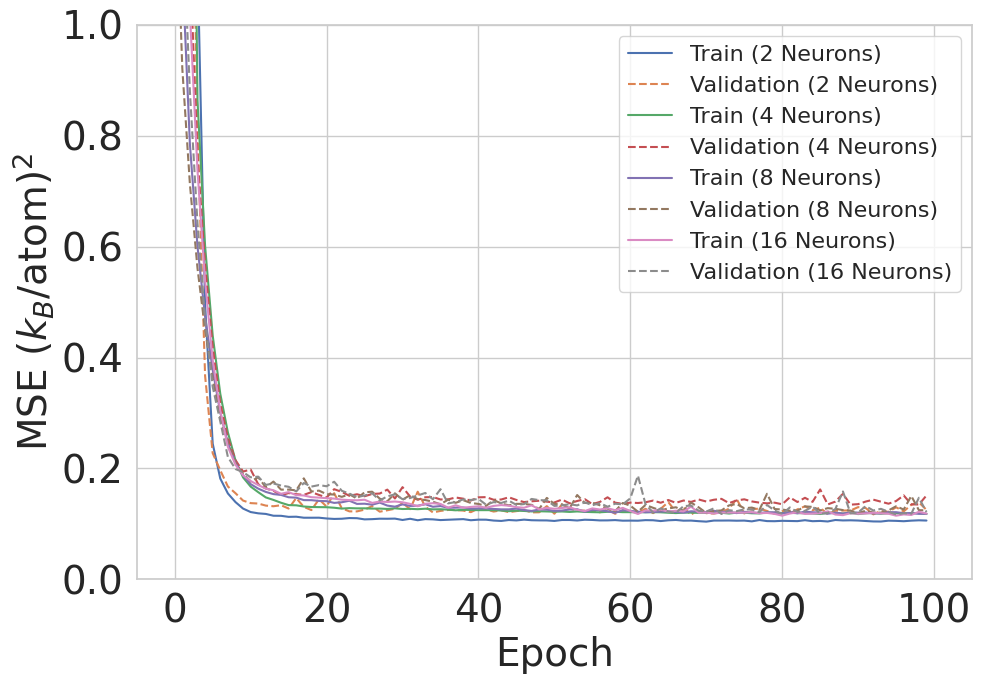

In [ ]:
# ------------------------------------------------------------
# Plot Loss Curves
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))

for neurons in neurons_list:
    history = histories[neurons]

    plt.plot(history.history['loss'], label=f'Train ({neurons} Neurons)')
    plt.plot(history.history['val_loss'], linestyle='--',
             label=f'Validation ({neurons} Neurons)')

plt.xlabel('Epoch', fontsize=28)
plt.ylabel(r'MSE $(k_B/\mathrm{atom})^2$', fontsize=28)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=16)

plt.xlim(-5, 105)
plt.ylim(0,1)

plt.grid(True)
plt.tight_layout()
plt.show()

## Final Neural Network Model (2 Neurons)

The neural network with a single hidden layer of 2 neurons is selected as the final model. This architecture provides the best balance between predictive accuracy and model complexity when compared to models with fewer or more neurons.  

The model is retrained using the full training procedure, and both the trained model and its learning history are saved for reproducibility.

In [ ]:
# ============================================================
# Final Neural Network Model (2 Neurons)
# ============================================================
# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
df_ml = pd.read_pickle("ml_final_dataset.pkl")

X = df_ml.drop(columns=["material_id", "Svib_300K_kB_atom"])
y = df_ml["Svib_300K_kB_atom"].values

# ------------------------------------------------------------
# Split (70 / 10 / 20)
# ------------------------------------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42
)

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# Model definition
# ------------------------------------------------------------
def build_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(
            2,
            activation="relu",
            kernel_regularizer=keras.regularizers.l1(0.01)
        ),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model

model = build_model(X_train_scaled.shape[1])

# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=1000,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training stopped at epoch: {len(history.history['loss'])}")

# ------------------------------------------------------------
# Save model and history
# ------------------------------------------------------------
model.save("2_neurons_final.keras")

with open("history_2_neurons_final.pkl", "wb") as f:
    pickle.dump(history.history, f)

# ------------------------------------------------------------
# Evaluation on TRAIN, VALIDATION, TEST
# ------------------------------------------------------------
y_train_pred = model.predict(X_train_scaled).flatten()
y_val_pred   = model.predict(X_val_scaled).flatten()
y_test_pred  = model.predict(X_test_scaled).flatten()

# MSE
mse_train = mean_squared_error(y_train, y_train_pred)
mse_val   = mean_squared_error(y_val, y_val_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# MAE
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val   = mean_absolute_error(y_val, y_val_pred)
mae_test  = mean_absolute_error(y_test, y_test_pred)

# R²
r2_train = r2_score(y_train, y_train_pred)
r2_val   = r2_score(y_val, y_val_pred)
r2_test  = r2_score(y_test, y_test_pred)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print("\nFinal Model Performance (2 neurons):")
print(f"Train MSE: {mse_train:.4e}")
print(f"Val   MSE: {mse_val:.4e}")
print(f"Test  MSE: {mse_test:.4e}")

print(f"\nTrain MAE: {mae_train:.4f}")
print(f"Val   MAE: {mae_val:.4f}")
print(f"Test  MAE: {mae_test:.4f}")

print(f"\nTrain R²: {r2_train:.4f}")
print(f"Val   R²: {r2_val:.4f}")
print(f"Test  R²: {r2_test:.4f}")



Training stopped at epoch: 119
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Final Model Performance (2 neurons):
Train MSE: 7.8630e-02
Val   MSE: 9.6029e-02
Test  MSE: 6.3747e-02

Train MAE: 0.1925
Val   MAE: 0.2065
Test  MAE: 0.1804

Train R²: 0.9585
Val   R²: 0.9526
Test  R²: 0.9683


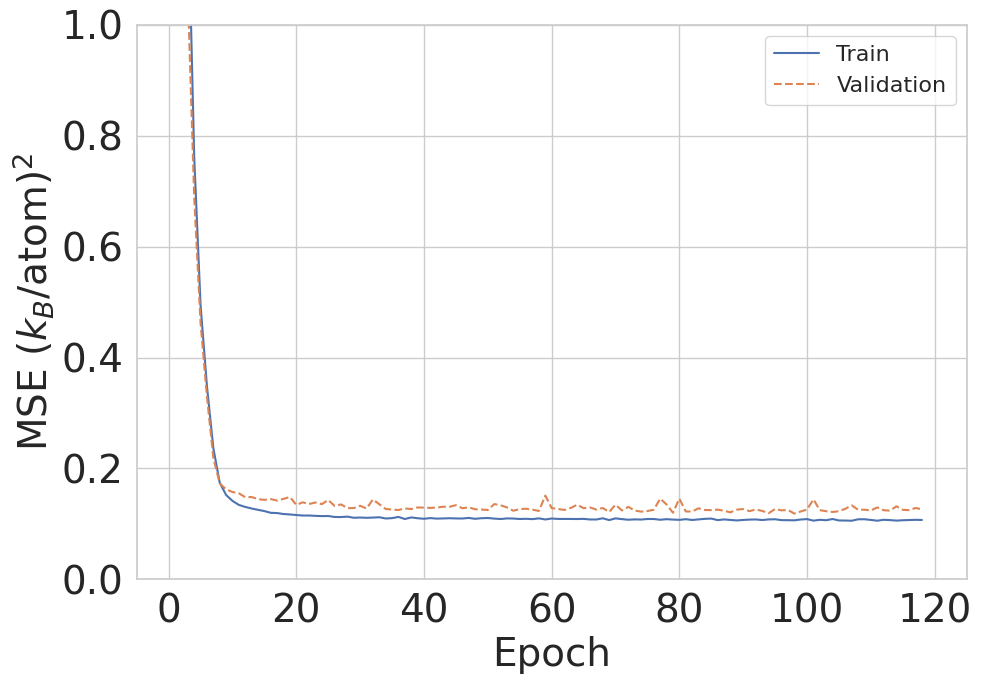

216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


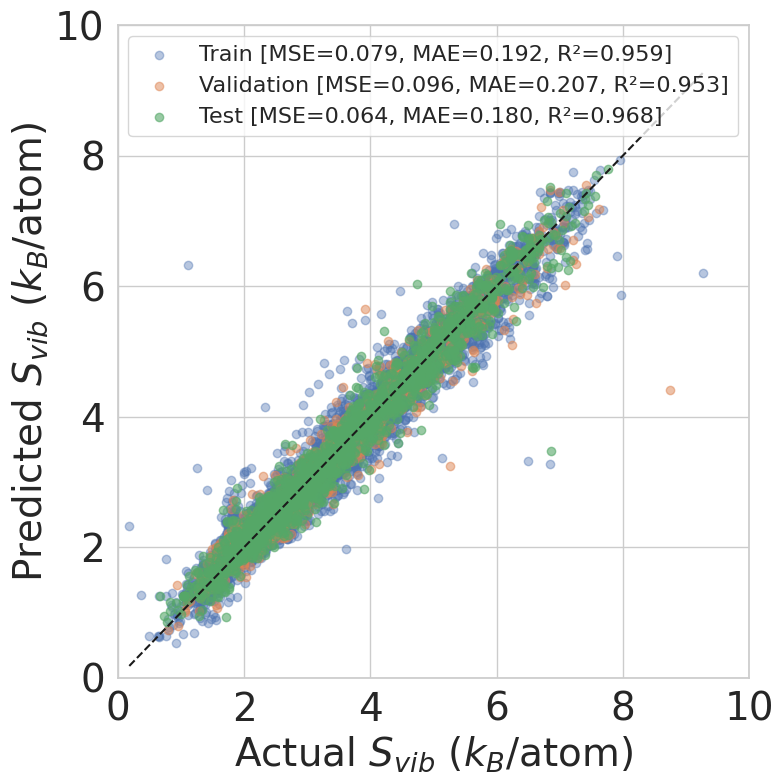

In [ ]:
# ============================================================
# 1. MSE vs Epoch
# ============================================================
plt.figure(figsize=(10, 7))

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], linestyle='--', label='Validation')

plt.xlabel('Epoch', fontsize=28)
plt.ylabel(r"MSE $(k_B/\mathrm{atom})^2$", fontsize=28)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=16)

plt.xlim(-5, 125)
plt.ylim(0,1)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 2. Parity Plot (Predicted vs Actual)
# ============================================================
plt.figure(figsize=(8, 8))

y_train_pred = model.predict(X_train_scaled).flatten()
y_val_pred = model.predict(X_val_scaled).flatten()

plt.scatter(
    y_train, y_train_pred, alpha=0.4,
    label=f"Train [MSE={mse_train:.3f}, MAE={mae_train:.3f}, R²={r2_train:.3f}]"
)

plt.scatter(
    y_val, y_val_pred, alpha=0.5,
    label=f"Validation [MSE={mse_val:.3f}, MAE={mae_val:.3f}, R²={r2_val:.3f}]"
)

plt.scatter(
    y_test, y_test_pred, alpha=0.6,
    label=f"Test [MSE={mse_test:.3f}, MAE={mae_test:.3f}, R²={r2_test:.3f}]"
)

min_val = min(
    y_train.min(), y_val.min(), y_test.min(),
    y_train_pred.min(), y_val_pred.min(), y_pred.min()
)
max_val = max(
    y_train.max(), y_val.max(), y_test.max(),
    y_train_pred.max(), y_val_pred.max(), y_pred.max()
)

plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.xlabel(r"Actual $S_{vib}$ $(k_B/\mathrm{atom})$", fontsize=28)
plt.ylabel(r"Predicted $S_{vib}$ $(k_B/\mathrm{atom})$", fontsize=28)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=16)
plt.xlim(0, 10)
plt.ylim(0,10)

plt.grid(True)
plt.tight_layout()
plt.show()

## SHAP Analysis

SHAP (SHapley Additive exPlanations) is used to interpret the trained neural network model and quantify feature contributions to vibrational entropy.

A subset of the dataset is used to reduce computational cost while retaining representative feature importance. The top features are identified based on mean absolute SHAP values.


Computing SHAP values...


PermutationExplainer explainer: 1975it [02:23, 13.78it/s]                          



Top 5 SHAP Features:
                               feature  importance
4                       density_atomic    0.513884
17              MagpieData mean Number    0.449309
6            formation_energy_per_atom    0.131598
20  MagpieData avg_dev MendeleevNumber    0.123834
35           MagpieData mean NpValence    0.122393

Top SHAP Feature: density_atomic

Saved: full ranking, top features, top feature


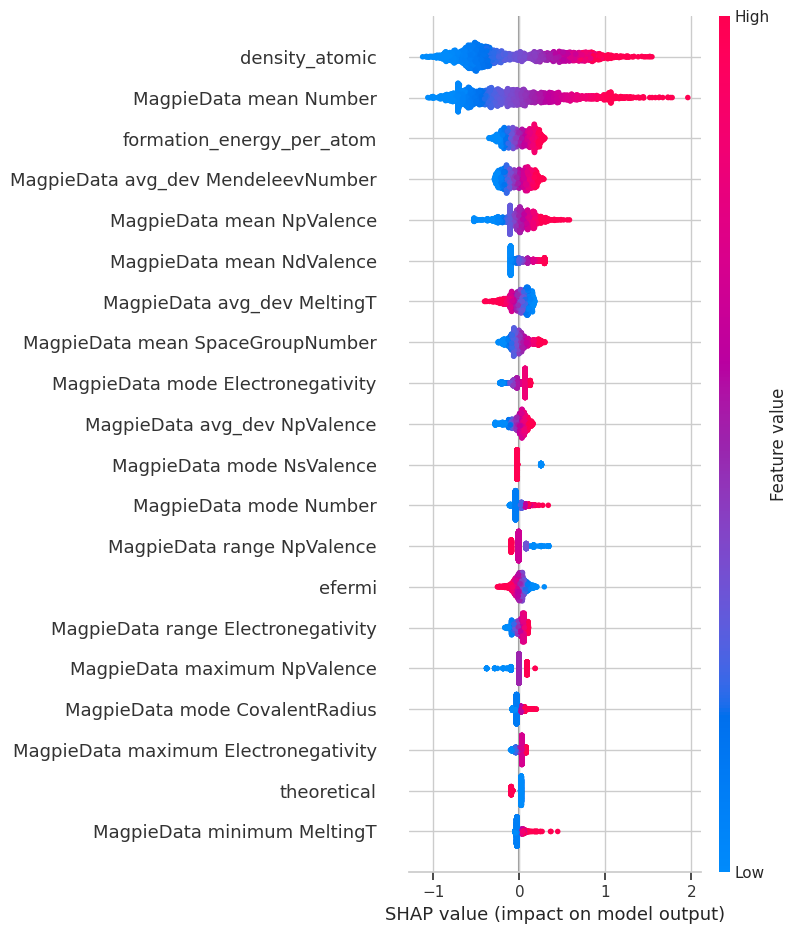

In [ ]:
# ============================================================
# SHAP Analysis
# ============================================================
# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
df_ml = pd.read_pickle("ml_final_dataset.pkl")

X = df_ml.drop(columns=["material_id", "Svib_300K_kB_atom"])
y = df_ml["Svib_300K_kB_atom"].values

feature_names = X.columns.tolist()

# ------------------------------------------------------------
# Same split (must match training)
# ------------------------------------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42
)

# ------------------------------------------------------------
# Scaling (same as training)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------
model = load_model("2_neurons_final.keras")

# ------------------------------------------------------------
# SHAP setup (subset version)
# ------------------------------------------------------------
print("\nComputing SHAP values...")

# Use subset for speed
background = shap.sample(X_train_scaled, len(X_train_scaled), random_state=42)
X_explain = shap.sample(X_test_scaled, len(X_test_scaled), random_state=42)

# Use general Explainer (stable behavior)
explainer = shap.Explainer(model, background)

shap_values = explainer(X_explain)

# ------------------------------------------------------------
# Feature importance
# ------------------------------------------------------------
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_abs_shap
}).sort_values(by="importance", ascending=False)

# ------------------------------------------------------------
# Extract top features
# ------------------------------------------------------------
TOP_N = 5
top_features_df = shap_importance.head(TOP_N)
top_feature = top_features_df.iloc[0]["feature"]

print(f"\nTop {TOP_N} SHAP Features:")
print(top_features_df)

print("\nTop SHAP Feature:", top_feature)

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
shap_importance.to_csv("shap_feature_importance_full.csv", index=False)
top_features_df.to_csv(f"top{TOP_N}_shap_features.csv", index=False)
pd.DataFrame({"feature": [top_feature]}).to_csv("top_feature.csv", index=False)

print("\nSaved: full ranking, top features, top feature")

# ------------------------------------------------------------
# SHAP summary plot
# ------------------------------------------------------------
shap.summary_plot(shap_values, X_explain, feature_names=feature_names)

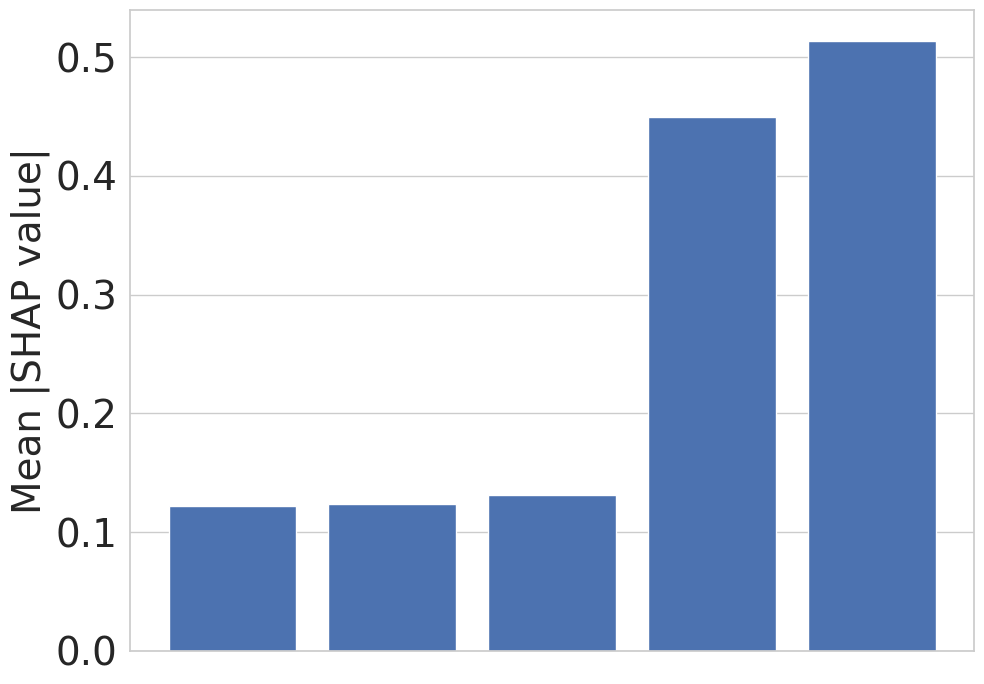

In [ ]:
name_map = {
    "density_atomic": "Atomic Volume",
    "MagpieData mean Number": "Mean Atomic Number",
    "formation_energy_per_atom": "Formation Energy per Atom",
    "MagpieData avg_dev MendeleevNumber": "Mendeleev Number (Std. Dev.)",
    "MagpieData mean NpValence": "Mean p-Valence Electrons"
}
top_features_df["clean_name"] = top_features_df["feature"].map(name_map)

plt.figure(figsize=(10, 7))

values = top_features_df["importance"][::-1]

plt.bar(range(len(values)), values)

plt.xticks([])

plt.ylabel("Mean |SHAP value|", fontsize=28)

plt.yticks(fontsize=28)

plt.tight_layout()
plt.show()

## Modeling using dominant descriptor

The relationship between vibrational entropy and the most influential descriptor identified through SHAP analysis was examined using a reduced feature set.

1. **Feature selection**  
   A reduced dataset was constructed using only the top-ranked feature, density_atomic, along with the target variable and material identifier. The quantity density_atomic corresponds to the atomic volume (Å³/atom), representing the local atomic packing.

2. **Model selection**  
   Three regression models were considered to capture the dependence of vibrational entropy on atomic volume:
   - Linear model  
   - Logarthmic model  
   - Log-Linear model  

3. **Model formulation**  
   - The linear model assumes a direct proportional relationship
   - The logarithmic model captures the strong nonlinear variation at low atomic volumes
   - The log-linear model combines logarithmic and linear terms to account for both low-volume curvature and near-linear behavior at larger atomic volumes, i.e., $S_{\mathrm{vib}} = a\ln(x) + bx + c$

4. **Model evaluation**  
   Model performance was evaluated using mean squared error (MSE), mean absolute error (MAE), and the coefficient of determination (R²) for both training and test datasets.

5. **Visualization and assessment**  
   - Fitted curves were compared with the data to examine the functional relationship  
   - Parity plots were used to assess agreement between predicted and actual values  

6. **Purpose of analysis**  
   This approach provides a simplified and physically interpretable view of the dominant role of atomic volume in governing vibrational entropy, and enables comparison with the neural network model.

Using feature: density_atomic

Linear Model:
Train -> MSE: 2.7964e-01, MAE: 0.3785, R²: 0.8518
Test  -> MSE: 2.5888e-01, MAE: 0.3841, R²: 0.8727

Logarithmic Model:
Train -> MSE: 2.5918e-01, MAE: 0.3685, R²: 0.8627
Test  -> MSE: 2.3843e-01, MAE: 0.3653, R²: 0.8827

Log-linear Model:
Train -> MSE: 2.4875e-01, MAE: 0.3553, R²: 0.8682
Test  -> MSE: 2.2637e-01, MAE: 0.3522, R²: 0.8887


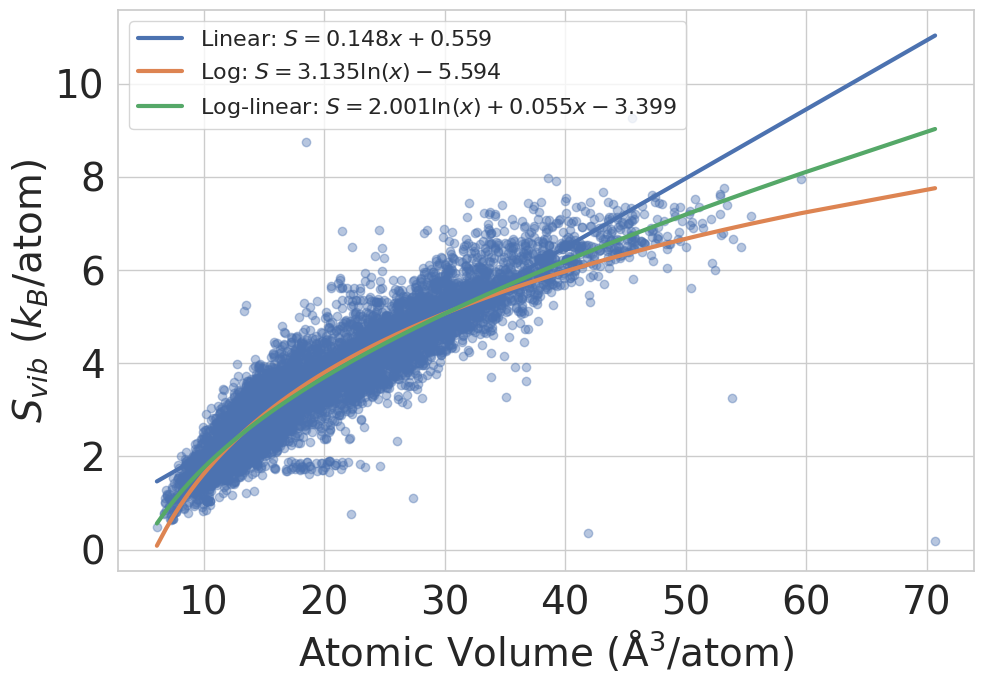

In [ ]:
# ============================================================
# Modeling using density_atomic (atomic volume)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
df = pd.read_pickle("ml_final_dataset.pkl")

top_feature = pd.read_csv("top_feature.csv")["feature"].iloc[0]
print("Using feature:", top_feature)

# ------------------------------------------------------------
# Build dataset
# ------------------------------------------------------------
df_reduced = df[["material_id", top_feature, "Svib_300K_kB_atom"]].copy()
df_reduced = df_reduced.rename(columns={top_feature: "density_atomic"})

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
X = df_reduced[["density_atomic"]].values
y = df_reduced["Svib_300K_kB_atom"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============================================================
# Models
# ============================================================

# Linear
lin = LinearRegression().fit(X_train, y_train)

# Logarithmic
X_train_log = np.log(np.clip(X_train, 1e-8, None))
X_test_log  = np.log(np.clip(X_test, 1e-8, None))

log_model = LinearRegression().fit(X_train_log, y_train)

# Log-linear
X_train_loglin = np.hstack([X_train_log, X_train])
X_test_loglin  = np.hstack([X_test_log, X_test])

loglin_model = LinearRegression().fit(X_train_loglin, y_train)

# ============================================================
# Predictions
# ============================================================

y_train_lin = lin.predict(X_train)
y_test_lin  = lin.predict(X_test)

y_train_log = log_model.predict(X_train_log)
y_test_log  = log_model.predict(X_test_log)

y_train_loglin = loglin_model.predict(X_train_loglin)
y_test_loglin  = loglin_model.predict(X_test_loglin)

# ============================================================
# Metrics
# ============================================================

def evaluate(name, y_tr, y_tr_pred, y_te, y_te_pred):
    print(f"\n{name} Model:")
    print(f"Train -> MSE: {mean_squared_error(y_tr, y_tr_pred):.4e}, "
          f"MAE: {mean_absolute_error(y_tr, y_tr_pred):.4f}, "
          f"R²: {r2_score(y_tr, y_tr_pred):.4f}")

    print(f"Test  -> MSE: {mean_squared_error(y_te, y_te_pred):.4e}, "
          f"MAE: {mean_absolute_error(y_te, y_te_pred):.4f}, "
          f"R²: {r2_score(y_te, y_te_pred):.4f}")

evaluate("Linear", y_train, y_train_lin, y_test, y_test_lin)
evaluate("Logarithmic", y_train, y_train_log, y_test, y_test_log)
evaluate("Log-linear", y_train, y_train_loglin, y_test, y_test_loglin)

# ============================================================
# Equations
# ============================================================

lin_eq = rf"Linear: $S = {lin.coef_[0]:.3f}x + {lin.intercept_:.3f}$"

log_eq = rf"Log: $S = {log_model.coef_[0]:.3f}\ln(x) {log_model.intercept_:.3f}$"

loglin_eq = rf"Log-linear: $S = {loglin_model.coef_[0]:.3f}\ln(x) + {loglin_model.coef_[1]:.3f}x {loglin_model.intercept_:.3f}$"

# ============================================================
# Fit Curve Plot
# ============================================================

x_sorted = np.sort(X.flatten())
x_sorted_2d = x_sorted.reshape(-1, 1)

plt.figure(figsize=(10, 7))

plt.scatter(X.flatten(), y, alpha=0.4)

plt.plot(x_sorted, lin.predict(x_sorted_2d),
         label=lin_eq, linewidth=3)

plt.plot(x_sorted,
         log_model.predict(np.log(np.clip(x_sorted_2d, 1e-8, None))),
         label=log_eq, linewidth=3)

plt.plot(x_sorted,
         loglin_model.predict(
             np.hstack([np.log(np.clip(x_sorted_2d, 1e-8, None)), x_sorted_2d])
         ),
         label=loglin_eq, linewidth=3)

plt.xlabel(r"Atomic Volume $(\mathrm{\AA}^3/\mathrm{atom})$", fontsize=28)
plt.ylabel(r"$S_{vib}$ $(k_B/\mathrm{atom})$", fontsize=28)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()


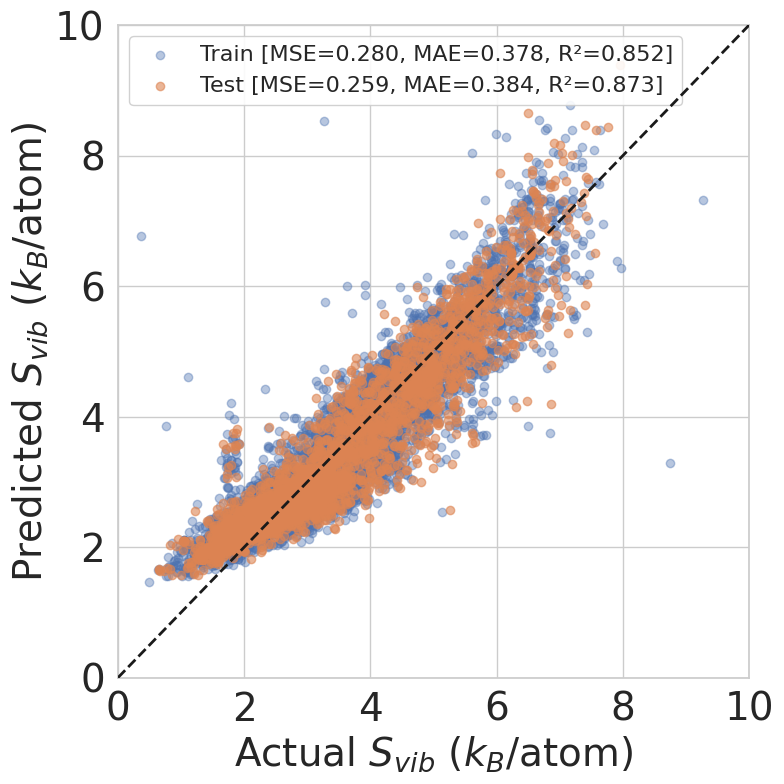

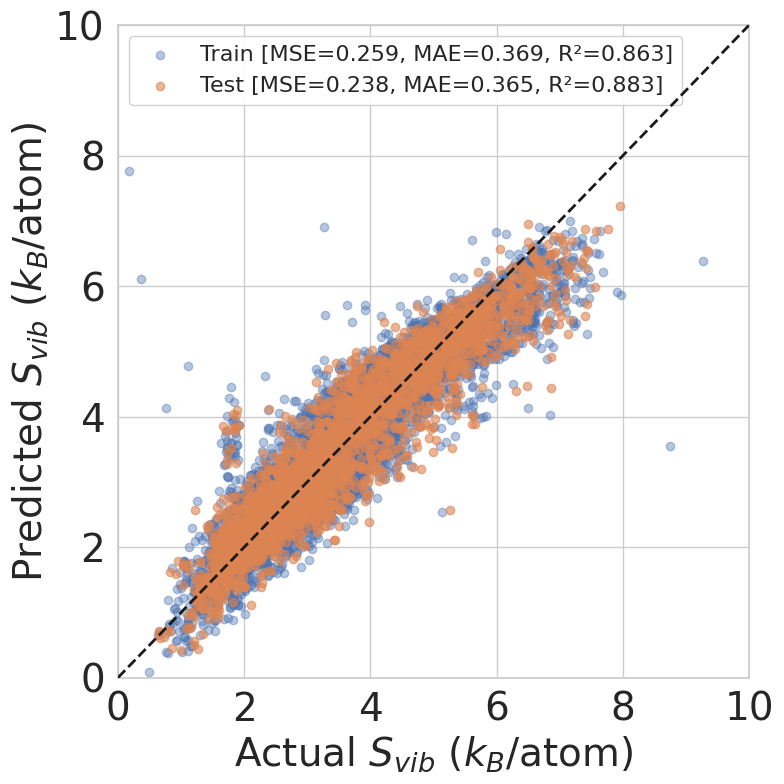

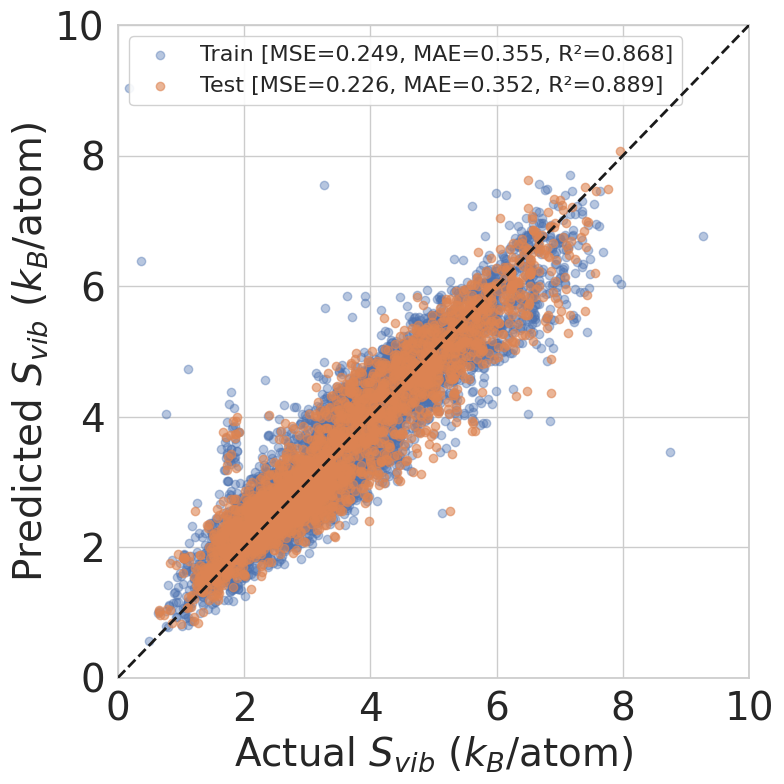

In [ ]:
# ============================================================
# Parity Plots (Linear, Logarithmic, Log-linear)
# ============================================================

models = [
    ("Linear", y_train_lin, y_test_lin),
    ("Logarithmic", y_train_log, y_test_log),
    ("Log-linear", y_train_loglin, y_test_loglin)
]

for name, y_tr_pred, y_te_pred in models:

    plt.figure(figsize=(8, 8))

    # Metrics (Train)
    mse_tr = mean_squared_error(y_train, y_tr_pred)
    mae_tr = mean_absolute_error(y_train, y_tr_pred)
    r2_tr  = r2_score(y_train, y_tr_pred)

    # Metrics (Test)
    mse_te = mean_squared_error(y_test, y_te_pred)
    mae_te = mean_absolute_error(y_test, y_te_pred)
    r2_te  = r2_score(y_test, y_te_pred)

    # Scatter
    plt.scatter(
        y_train, y_tr_pred, alpha=0.4,
        label=f"Train [MSE={mse_tr:.3f}, MAE={mae_tr:.3f}, R²={r2_tr:.3f}]"
    )

    plt.scatter(
        y_test, y_te_pred, alpha=0.6,
        label=f"Test [MSE={mse_te:.3f}, MAE={mae_te:.3f}, R²={r2_te:.3f}]"
    )

    # Diagonal
    plt.plot([0, 10], [0, 10], 'k--', linewidth=2, zorder=10)

    # Limits (adjust if needed)
    plt.xlim(0, 10)
    plt.ylim(0, 10)

    # Labels
    plt.xlabel(r"Actual $S_{vib}$ $(k_B/\mathrm{atom})$", fontsize=28)
    plt.ylabel(r"Predicted $S_{vib}$ $(k_B/\mathrm{atom})$", fontsize=28)

    plt.xticks(fontsize=28)
    plt.yticks(fontsize=28)

    # Legend
    plt.legend(
        fontsize=16,
        frameon=True,
        fancybox=True,
        framealpha=0.9,
        loc="upper left"
    )

    plt.grid(True)
    plt.tight_layout()

    plt.show()

### Error analysis across atomic volume regimes

To evaluate model performance across different atomic volume regimes, the dataset was divided into equal-population bins based on atomic volume. The mean squared error (MSE) was computed within each bin for the linear, logarithmic, and logarithmic–linear models.

The resulting bar chart provides a direct comparison of model performance as a function of atomic volume, enabling identification of regimes where each functional form performs more effectively. This analysis complements the overall regression metrics and offers insight into the variation of model accuracy across the data range.


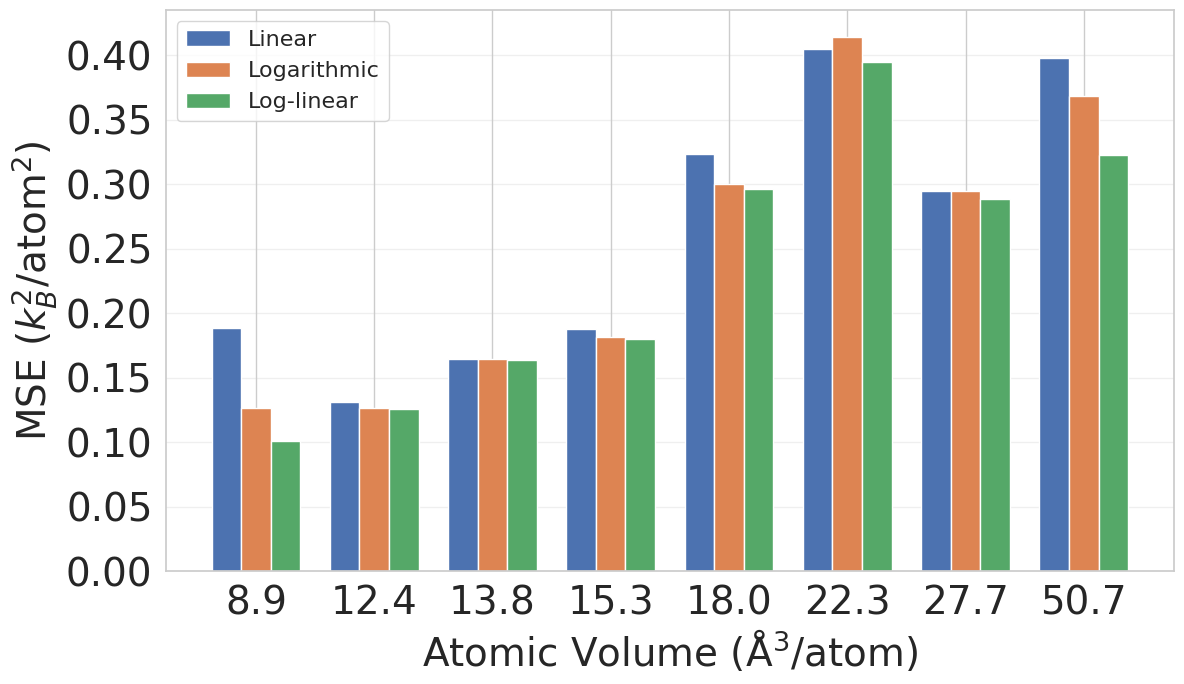

In [ ]:
# ============================================================
# Binned MSE vs Atomic Volume (Bar Plot)
# ============================================================

# -----------------------------------------
# Use ALL data (for smooth trend analysis)
# -----------------------------------------
x_all = X.flatten()
y_all = y

# Predictions (consistent with your models)
y_lin_all = lin.predict(X)
y_log_all = log_model.predict(np.log(np.clip(X, 1e-8, None)))
y_loglin_all = loglin_model.predict(
    np.hstack([np.log(np.clip(X, 1e-8, None)), X])
)

# -----------------------------------------
# Create bins (equal population)
# -----------------------------------------
n_bins = 8
bins = np.quantile(x_all, np.linspace(0, 1, n_bins + 1))

# Bin labels (midpoints)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

mse_lin = []
mse_log = []
mse_loglin = []

# -----------------------------------------
# Compute MSE per bin
# -----------------------------------------
for i in range(n_bins):
    mask = (x_all >= bins[i]) & (x_all < bins[i+1])

    # Avoid empty bins
    if np.sum(mask) < 5:
        mse_lin.append(np.nan)
        mse_log.append(np.nan)
        mse_loglin.append(np.nan)
        continue

    y_true_bin = y_all[mask]

    mse_lin.append(mean_squared_error(y_true_bin, y_lin_all[mask]))
    mse_log.append(mean_squared_error(y_true_bin, y_log_all[mask]))
    mse_loglin.append(mean_squared_error(y_true_bin, y_loglin_all[mask]))

# -----------------------------------------
# Bar plot
# -----------------------------------------
x_pos = np.arange(len(bin_centers))
width = 0.25

plt.figure(figsize=(12, 7))

plt.bar(x_pos - width, mse_lin, width, label="Linear")
plt.bar(x_pos, mse_log, width, label="Logarithmic")
plt.bar(x_pos + width, mse_loglin, width, label="Log-linear")

# X labels as bin centers
plt.xticks(x_pos, [f"{bc:.1f}" for bc in bin_centers], fontsize=28)

plt.xlabel(r"Atomic Volume $(\mathrm{\AA}^3/\mathrm{atom})$", fontsize=28)
plt.ylabel(r"MSE $(k_B^2/\mathrm{atom}^2)$", fontsize=28)

plt.yticks(fontsize=28)

plt.legend(fontsize=16)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Temperature-dependent vibrational entropy modeling

Temperature-dependent vibrational entropy values were computed using the script `SVib_kB_PhononDB_T.py` over the temperature range of 100–500 K with a step size of 50 K. This dataset was subsequently combined with the dominant structural descriptor, `density_atomic`, to construct a unified modeling framework capturing both structural and thermal effects.

To account for the distinct physical behavior of lattice vibrations at different temperatures, a piecewise functional form was adopted. The transition temperature \(T_c\) separating the low- and high-temperature regimes was determined directly from the data by minimizing validation error.

The final model is expressed as:

- **Low temperature regime (\(T < T_c\))**  
  \[
  $S_{vib} = a_1 \log(x) + b_1 x + c_1 T^3 + d_1$
  \]

- **High temperature regime (\(T $\ge$ T_c\))**  
  \[
  $S_{vib} = a_2 \log(x) + b_2 x + c_2 \log(T) + d_2$
  \]

where \(x\) denotes `density_atomic` (Å³/atom) and \(T\) is the temperature in Kelvin.

The \($T^3$\) dependence in the low-temperature regime is consistent with the Debye model, reflecting the suppression of phonon modes, while the logarithmic dependence at higher temperatures captures the gradual saturation of vibrational entropy.

The parity plot below demonstrates the predictive performance of the model on both training and test datasets.



The model shows good agreement between predicted and computed values across the full temperature range, with no significant overfitting observed between training and test data. The remaining scatter reflects intrinsic variability arising from factors beyond atomic density, such as bonding characteristics and phonon dispersion, which are not explicitly included in the model.

Merged dataset shape: (88794, 4)
Saved:
✔ svib_density_temperature_dataset.csv
✔ svib_density_temperature_dataset.pkl

Optimal Tc: 200.00 K
Training MSE (for Tc selection): 3.4698e-01

Train:
MSE: 3.4698e-01
MAE: 0.3898
R² : 0.8864

Test:
MSE: 3.3762e-01
MAE: 0.3831
R² : 0.8876

--- Final Model Equations ---

Low T (T < Tc):
S_vib = a1 log(x) + b1 x + c1 T^3 + d1
Coefficients: [3.31199111e-01 8.68861064e-02 2.81271362e-07] Intercept: -1.6302511598493266

High T (T ≥ Tc):
S_vib = a2 log(x) + b2 x + c2 log(T) + d2
Coefficients: [1.86879145 0.06045998 2.46160957] Intercept: -17.114856567705967


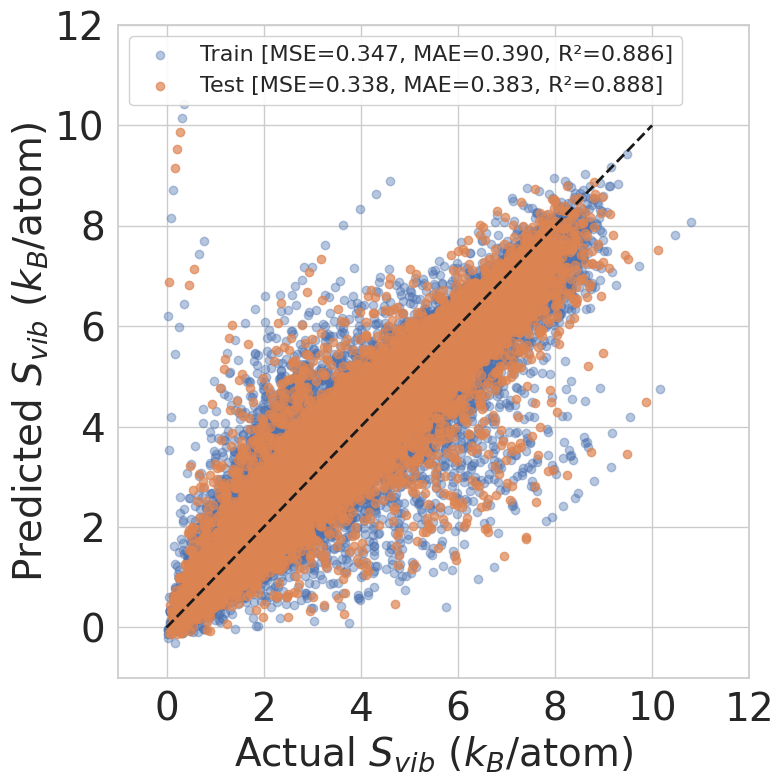

In [ ]:
# ============================================================
# Optimal Piecewise Model
# ============================================================

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
df_temp = pd.read_csv("SVib_Temperature_Dependent.csv")
df_temp.columns = ["material_id", "Temperature", "Svib_300K_kB_atom"]

df_density = pd.read_pickle("svib_density_dataset.pkl")

# ------------------------------------------------------------
# Merge datasets
# ------------------------------------------------------------
df_merged = df_temp.merge(
    df_density[["material_id", "density_atomic"]],
    on="material_id",
    how="inner"
)

print("Merged dataset shape:", df_merged.shape)

# ------------------------------------------------------------
# Save new dataset
# ------------------------------------------------------------
df_merged.to_csv("svib_density_temperature_dataset.csv", index=False)
df_merged.to_pickle("svib_density_temperature_dataset.pkl")

print("Saved:")
print("✔ svib_density_temperature_dataset.csv")
print("✔ svib_density_temperature_dataset.pkl")

x = df_merged["density_atomic"].values
T = df_merged["Temperature"].values
y = df_merged["Svib_300K_kB_atom"].values

# ------------------------------------------------------------
# Train / Test split (70 / 30)
# ------------------------------------------------------------
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)

# ------------------------------------------------------------
# Feature builders
# ------------------------------------------------------------
def build_low(x, T):
    x = np.asarray(x)
    T = np.asarray(T)
    return np.column_stack([np.log(x), x, T**3])

def build_high(x, T):
    x = np.asarray(x)
    T = np.asarray(T)
    return np.column_stack([np.log(x), x, np.log(T)])

# ------------------------------------------------------------
# Tc search (based on training error)
# ------------------------------------------------------------
Tc_candidates = np.sort(df_merged["Temperature"].unique())

best_Tc = None
best_mse = np.inf

for Tc in Tc_candidates:

    low_train = T[train_idx] < Tc
    high_train = T[train_idx] >= Tc

    if np.sum(low_train) < 50 or np.sum(high_train) < 50:
        continue

    model_low = LinearRegression().fit(
        build_low(x[train_idx][low_train], T[train_idx][low_train]),
        y[train_idx][low_train]
    )

    model_high = LinearRegression().fit(
        build_high(x[train_idx][high_train], T[train_idx][high_train]),
        y[train_idx][high_train]
    )

    # Training prediction
    train_x = x[train_idx]
    train_T = T[train_idx]

    y_train_pred_tmp = np.zeros(len(train_idx))

    low = train_T < Tc
    high = train_T >= Tc

    if np.any(low):
        y_train_pred_tmp[low] = model_low.predict(
            build_low(train_x[low], train_T[low])
        )

    if np.any(high):
        y_train_pred_tmp[high] = model_high.predict(
            build_high(train_x[high], train_T[high])
        )

    mse = mean_squared_error(y[train_idx], y_train_pred_tmp)

    if mse < best_mse:
        best_mse = mse
        best_Tc = Tc

print(f"\nOptimal Tc: {best_Tc:.2f} K")
print(f"Training MSE (for Tc selection): {best_mse:.4e}")

# ------------------------------------------------------------
# Train FINAL model (on full training data)
# ------------------------------------------------------------
train_x = x[train_idx]
train_T = T[train_idx]
train_y = y[train_idx]

low_mask = train_T < best_Tc
high_mask = train_T >= best_Tc

model_low = LinearRegression().fit(
    build_low(train_x[low_mask], train_T[low_mask]),
    train_y[low_mask]
)

model_high = LinearRegression().fit(
    build_high(train_x[high_mask], train_T[high_mask]),
    train_y[high_mask]
)

# ------------------------------------------------------------
# Save models
# ------------------------------------------------------------
joblib.dump(model_low, "piecewise_low_T3_model.pkl")
joblib.dump(model_high, "piecewise_high_logT_model.pkl")

pd.DataFrame({"Tc": [best_Tc]}).to_csv("piecewise_Tc.csv", index=False)

# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------
def predict_piecewise(x, T):
    x = np.asarray(x)
    T = np.asarray(T)

    y_pred = np.zeros_like(x)

    low = T < best_Tc
    high = T >= best_Tc

    if np.any(low):
        y_pred[low] = model_low.predict(build_low(x[low], T[low]))

    if np.any(high):
        y_pred[high] = model_high.predict(build_high(x[high], T[high]))

    return y_pred

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------
y_train_pred = predict_piecewise(x[train_idx], T[train_idx])
y_test_pred = predict_piecewise(x[test_idx], T[test_idx])

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
def print_metrics(name, y_true, y_pred):
    print(f"\n{name}:")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.4e}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"R² : {r2_score(y_true, y_pred):.4f}")

print_metrics("Train", y[train_idx], y_train_pred)
print_metrics("Test", y[test_idx], y_test_pred)

# ------------------------------------------------------------
# Final equations
# ------------------------------------------------------------
print("\n--- Final Model Equations ---")

print("\nLow T (T < Tc):")
print("S_vib = a1 log(x) + b1 x + c1 T^3 + d1")
print("Coefficients:", model_low.coef_, "Intercept:", model_low.intercept_)

print("\nHigh T (T ≥ Tc):")
print("S_vib = a2 log(x) + b2 x + c2 log(T) + d2")
print("Coefficients:", model_high.coef_, "Intercept:", model_high.intercept_)

# ------------------------------------------------------------
# Metrics (for legend)
# ------------------------------------------------------------
mse_train = mean_squared_error(y[train_idx], y_train_pred)
mae_train = mean_absolute_error(y[train_idx], y_train_pred)
r2_train  = r2_score(y[train_idx], y_train_pred)

mse_test = mean_squared_error(y[test_idx], y_test_pred)
mae_test = mean_absolute_error(y[test_idx], y_test_pred)
r2_test  = r2_score(y[test_idx], y_test_pred)

# ------------------------------------------------------------
# Parity Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 8))

# Scatter with metrics in legend
plt.scatter(
    y[train_idx], y_train_pred, alpha=0.4,
    label=f"Train [MSE={mse_train:.3f}, MAE={mae_train:.3f}, R²={r2_train:.3f}]"
)

plt.scatter(
    y[test_idx], y_test_pred, alpha=0.7,
    label=f"Test [MSE={mse_test:.3f}, MAE={mae_test:.3f}, R²={r2_test:.3f}]"
)

# Diagonal line (perfect prediction)
plt.plot([0, 10], [0, 10], 'k--', linewidth=2, zorder=10)

# Axis limits
plt.xlim(-1, 12)
plt.ylim(-1, 12)

# Labels
plt.xlabel(r"Actual $S_{vib}$ $(k_B/\mathrm{atom})$", fontsize=28)
plt.ylabel(r"Predicted $S_{vib}$ $(k_B/\mathrm{atom})$", fontsize=28)

# Tick size
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)

# Legend
plt.legend(
    fontsize=16,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    #borderpad=1.2,
    loc="upper left"
)

# Grid
plt.grid(True)

plt.tight_layout()
plt.show()